Step 1: Importing the required libraries


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
data=pd.read_csv("Austin-2019-01-01-to-2023-07-22.csv")

In [9]:
df=pd.DataFrame(data)

In [13]:
print(df.tail())

        name datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
1659  Austin  7/18/23    105.1     77.6  91.4         107.2          77.6   
1660  Austin  7/19/23    103.8     77.6  90.7         107.6          77.6   
1661  Austin  7/20/23    103.2     79.6  90.4         104.8          79.6   
1662  Austin  7/21/23    101.6     76.4  89.0         101.5          76.4   
1663  Austin  7/22/23    103.2     77.6  89.8         106.1          77.6   

      feelslike   dew  humidity  ...  solarenergy  uvindex  severerisk  \
1659       94.3  67.6      51.5  ...         24.1        9        30.0   
1660       94.6  69.3      54.3  ...         23.9        9        60.0   
1661       93.7  68.3      53.3  ...         23.9        9        60.0   
1662       90.4  66.0      52.9  ...         23.6        8        30.0   
1663       93.1  67.8      51.6  ...         22.8        8        30.0   

                  sunrise               sunset  moonphase  \
1659  2023-07-18T06:41:12  2023

Step 3: Data Preprocessing
Clean and preprocess the data by handling missing values, removing outliers and scaling variables. Split the dataset into training and testing sets. Preprocessing ensures the model isn’t biased or skewed due to incomplete or inconsistent data leading to reliable predictions.

In [15]:
"""data.dropna(): This function is used to remove rows containing missing (NaN) values in the specified columns (features and target). It's important to handle missing data to avoid errors in model training."""

"data.dropna(): This function is used to remove rows containing missing (NaN) values in the specified columns (features and target). It's important to handle missing data to avoid errors in model training."

In [17]:
features=["tempmax","tempmin","humidity","dew"]
target="precip"
data=data.dropna(subset=features+[target])

Step 4: Feature Selection
Identify which weather variables i.e features are most correlated with rainfall. For example humidity might have a stronger correlation than temperature. Selecting relevant features improves model performance and reduces computational complexity by focusing on important variables.

In [18]:
x=data[features]
y=data[target]

Step 5: Model Training
Use the training dataset to fit a linear regression model. Model learns the relationship between the independent variables (humidity, temperature) and rainfall.

In [19]:
"""train_test_split(): This function splits the dataset into training and testing sets"""

'train_test_split(): This function splits the dataset into training and testing sets'

In [22]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

test_size=0.2 indicates that 20% of the data will be used for testing and the remaining 80% will be used for training.
random_state=42 ensures that the split is reproducible.

In [23]:
"""model.fit(): Trains the linear regression model on the training data. The model learns the relationship between the features and the target variable."""

'model.fit(): Trains the linear regression model on the training data. The model learns the relationship between the features and the target variable.'

In [55]:
model=RandomForestRegressor(
    n_estimators=50, 
    max_depth=3,       # Prevents it from memorizing noise
    min_samples_leaf=20,  # Ensures it finds general patterns
    random_state=42
)

ytrain_log = np.log1p(ytrain)

model.fit(xtrain,ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [56]:
ypred=np.expm1(model.predict(xtest))

In [26]:
"""Step 7: Prediction and Visualziing Results
Input new data into the trained model to predict rainfall. 
For instance, given a specific temperature and humidity,
the model forecasts rainfall levels. Prediction is the
ultimate goal, enabling actionable insights, such as
preparing for heavy rainfall or managing agricultural 
schedules.

mean_squared_error(): Calculates the Mean Squared Error
(MSE), which measures the average squared differences 
between actual and predicted values. A lower MSE 
indicates better model performance.

np.sqrt(): Computes the Root Mean Squared Error (RMSE)
, which is the square root of MSE. It gives an error
metric in the same unit as the target variable 
(rainfall).
r2_score(): Calculates the R-squared value, which 
indicates how well the model explains the variance in 
the data. Value ranges from 0 to 1, with higher values 
indicating a better fit."""

'Step 7: Prediction and Visualziing Results\nInput new data into the trained model to predict rainfall. For instance, given a specific temperature and humidity, the model forecasts rainfall levels. Prediction is the ultimate goal, enabling actionable insights, such as preparing for heavy rainfall or managing agricultural schedules.\n\nmean_squared_error(): Calculates the Mean Squared Error (MSE), which measures the average squared differences between actual and predicted values. A lower MSE indicates better model performance.\nnp.sqrt(): Computes the Root Mean Squared Error (RMSE), which is the square root of MSE. It gives an error metric in the same unit as the target variable (rainfall).\nr2_score(): Calculates the R-squared value, which indicates how well the model explains the variance in the data. Value ranges from 0 to 1, with higher values indicating a better fit.'

Mean Squared Error: 0.05075579597892369
Root Mean Squared Error: 0.22529047023548
R-squared: 0.14930229130958017


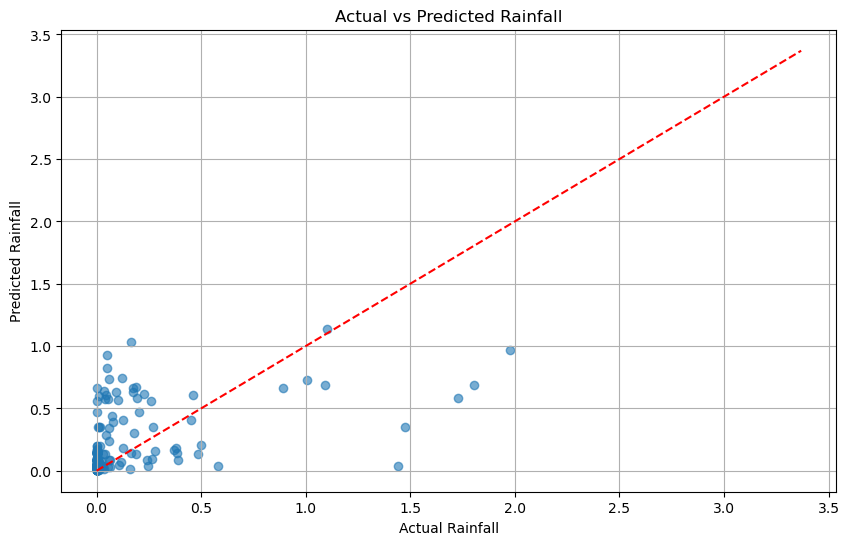

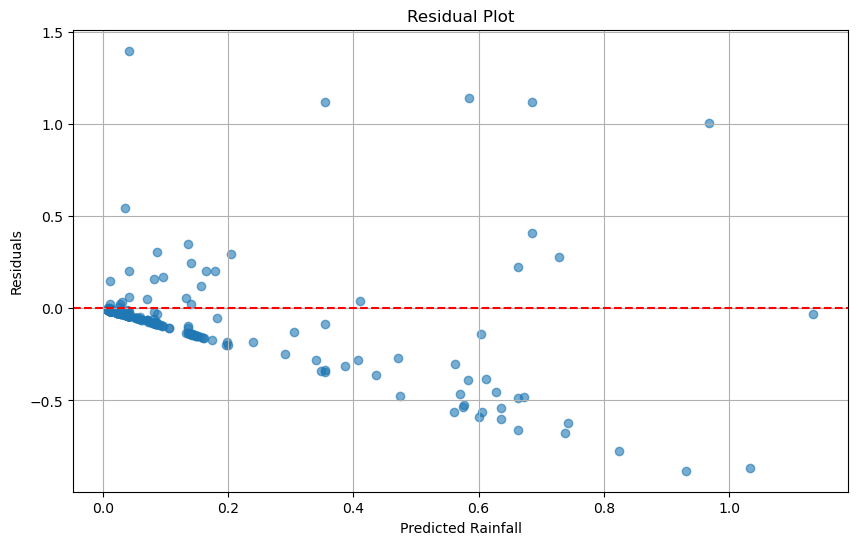

In [57]:
"""Step 7: Prediction and Visualziing Results
Input new data into the trained model to predict rainfall. 
For instance, given a specific temperature and humidity,
the model forecasts rainfall levels. Prediction is the
ultimate goal, enabling actionable insights, such as
preparing for heavy rainfall or managing agricultural 
schedules.

mean_squared_error(): Calculates the Mean Squared Error
(MSE), which measures the average squared differences 
between actual and predicted values. A lower MSE 
indicates better model performance.

np.sqrt(): Computes the Root Mean Squared Error (RMSE)
, which is the square root of MSE. It gives an error
metric in the same unit as the target variable 
(rainfall).

r2_score(): Calculates the R-squared value, which 
indicates how well the model explains the variance in 
the data. Value ranges from 0 to 1, with higher values 
indicating a better fit."""

import matplotlib.pyplot as plt
mse=mean_squared_error(ytest,ypred)
rmse=np.sqrt(mse)

r2=r2_score(ytest,ypred)


print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")


#visualization

plt.figure(figsize=(10,6))
plt.scatter(ytest, ypred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Rainfall')
plt.xlabel('Actual Rainfall')
plt.ylabel('Predicted Rainfall')
plt.grid()
plt.show()

residuals = ytest - ypred
plt.figure(figsize=(10,6))
plt.scatter(ypred,residuals,alpha=0.6)
plt.axhline(y=0,color='red',linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Rainfall')
plt.ylabel('Residuals')
plt.grid()
plt.show()

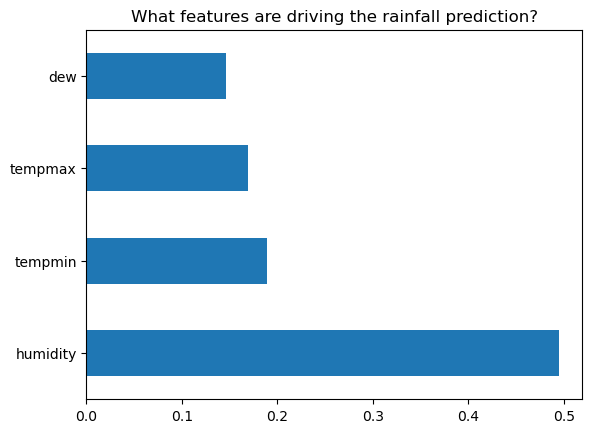

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=xtrain.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("What features are driving the rainfall prediction?")
plt.show()

The model showed reasonable performance with a Root Mean Squared Error (RMSE) of 0.22 and an R-squared value of 0.15 approx, indicating some predictive capability but room for improvement. Visualizations like the Actual vs Predicted Rainfall plot and the Residual Plot helped analyze model accuracy and identify areas where predictions deviated from actual values.